In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [ ]:
# Standard library
import sys
from pathlib import Path
import importlib

# Third-party libraries
import numpy as np
from qiskit.circuit.library import RZGate
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Local helper path
helpers_dir = Path("../").resolve()
if str(helpers_dir) not in sys.path:
    sys.path.insert(0, str(helpers_dir))

# Local modules
import qpe_helpers
import helpers

# Reload local modules while actively editing them
importlib.reload(qpe_helpers)
importlib.reload(helpers)

# Specific local imports
from qpe_helpers import algorithm, calculate_Q, distance
from helpers import SequenceDB, db_to_nn

# Global Variables

In [ ]:
h1 = 0.79605
h2 = -0.18092
h3 = -0.32096
t = np.pi/(8*h1)

# Graphing Settings

In [3]:
# --- APS-style global settings ---
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Using Cluster Data

In [6]:
data = np.load("exotic_set2_max10.npz", allow_pickle=True)

N_s = data["N_s"]
estimated_phase = data["estimated_phase"]
holevo_variance = data["holevo_variance"]
holevo_std = data["holevo_std"]
original_k_list = data["original_k_list"]
original_beta_list = data["original_beta_list"]
original_m_list = data["original_m_list"]
tilde_phi_list = data["tilde_phi_list"]
cu_gate_list = data["cu_gate_list"]
beta_gate_dict = data["beta_gate_dict"].item()

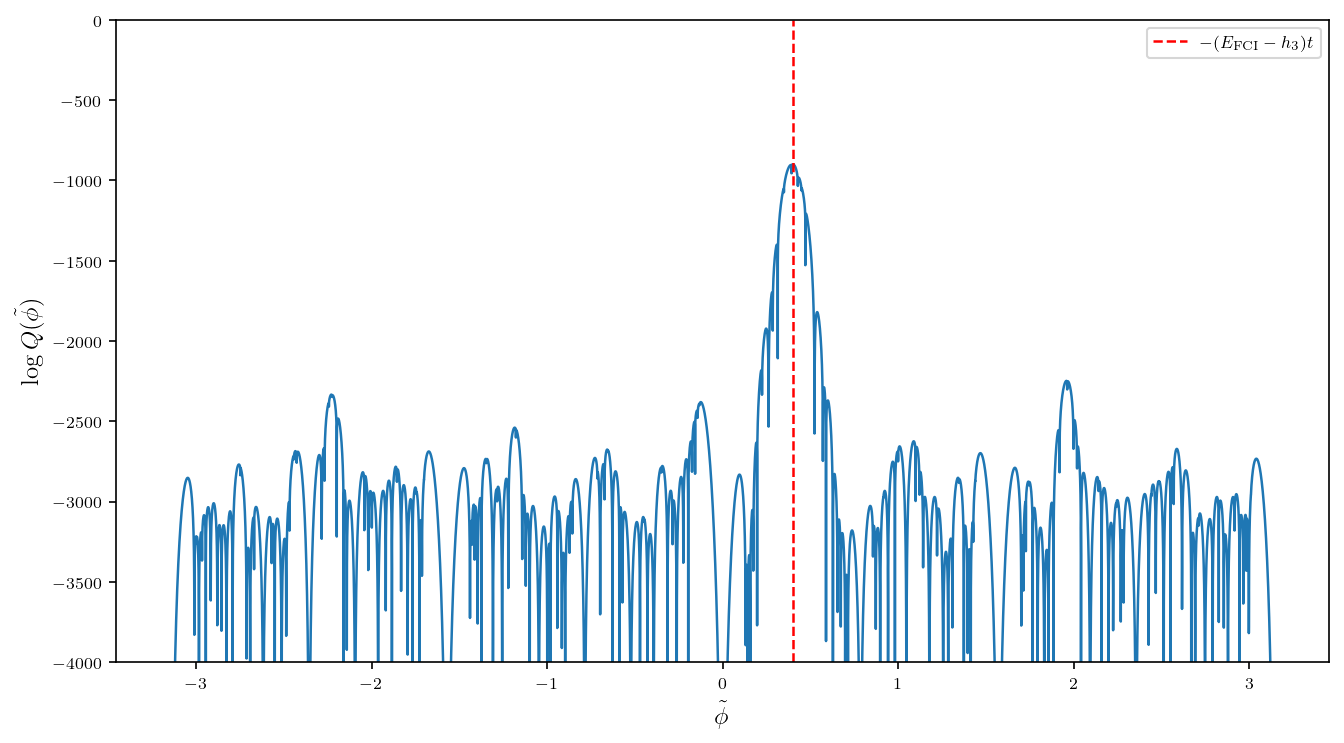

In [15]:
logQ_list = np.array([
    calculate_Q(original_k_list, original_beta_list, original_m_list, tilde_phi)
    for tilde_phi in tilde_phi_list
])

# Convert phase axis from [0, 2pi) to [-pi, pi)
tilde_phi_signed = (tilde_phi_list + np.pi) % (2 * np.pi) - np.pi

# Sort so the line plot is continuous
sort_idx = np.argsort(tilde_phi_signed)

plt.figure(figsize=(9, 5))
plt.plot(tilde_phi_signed[sort_idx], logQ_list[sort_idx])


E_FCI = -1.13731
phi_target = -(E_FCI - h3) * t
phi_target_signed = (phi_target + np.pi) % (2 * np.pi) - np.pi
plt.axvline(phi_target_signed, linestyle="--", label=r"$-(E_{\rm FCI}-h_3)t$", color='red')

plt.xlabel(r"$\tilde{\phi}$", fontsize=12)
plt.ylabel(r"$\log Q(\tilde{\phi})$", fontsize=12)
plt.ylim(-4_000, 0)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# estimated_phase is already in [-pi, pi)
E_est = h3 - estimated_phase / t

# Holevo phase uncertainty -> energy uncertainty
sigma_phi = holevo_std
sigma_E = sigma_phi / t

print(f"Estimated phase = {estimated_phase:.8f} rad")
print(f"Holevo std phase uncertainty = {sigma_phi:.8f} rad")
print(f"Estimated energy = {E_est:.8f} Ha")
print(f"Energy uncertainty = {sigma_E:.8f} Ha")
print(f"|E - E_FCI| = {np.abs(E_est - E_FCI):.8f} Ha")

Estimated phase = 0.39895874 rad
Holevo std phase uncertainty = 0.00508266 rad
Estimated energy = -1.12969911 Ha
Energy uncertainty = 0.01030319 Ha
|E - E_FCI| = 0.00761089 Ha


In [10]:
U_h1_exact = np.asarray(RZGate(h1 * t).to_matrix(), dtype=complex)
U_h2_exact = np.asarray(RZGate(h2 * t).to_matrix(), dtype=complex)
U_beta_exact = np.asarray(RZGate(np.pi / 2).to_matrix(), dtype=complex)

U_h1_approx = np.asarray(cu_gate_list[0], dtype=complex)
U_h2_approx = np.asarray(cu_gate_list[2], dtype=complex)
U_beta_approx = beta_gate_dict[round(float(np.pi / 2), 12)].to_matrix()

print("distance Rz(h1*t):", distance(U_h1_exact, U_h1_approx))
print("distance Rz(h2*t):", distance(U_h2_exact, U_h2_approx))
print("distance Rz(pi/2):", distance(U_beta_exact, U_beta_approx))

distance Rz(h1*t): 0.0027212975087475754
distance Rz(h2*t): 0.0006222435403874371
distance Rz(pi/2): 1.0536712127723509e-08


# Saving Data for Final Plot

In [16]:
np.savez(
    "final_plot_exotic_set2.npz",
    x_axis=tilde_phi_signed[sort_idx],
    y_axis=logQ_list[sort_idx],
    estimated_phase=estimated_phase,
    sigma_phi=sigma_phi,
    E_est=E_est,
    sigma_E=sigma_E
)